In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/diabetes-classification/sample_submission.csv
/kaggle/input/diabetes-classification/train.csv
/kaggle/input/diabetes-classification/test.csv


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
train=pd.read_csv('../input/diabetes-classification/train.csv')
train.head()

,p_id,no_times_pregnant,glucose_concentration,blood_pressure,skin_fold_thickness,serum_insulin,bmi,diabetes pedigree,age,diabetes
0,316,2,112,68,22,94,34.1,0.315,26,0
1,25,11,143,94,33,146,36.6,0.254,51,1
2,710,2,93,64,32,160,38.0,0.674,23,1
3,658,1,120,80,48,200,38.9,1.162,41,0
4,542,3,128,72,25,190,32.4,0.549,27,1


In [4]:
test=pd.read_csv('../input/diabetes-classification/test.csv')
test.head()

,p_id,no_times_pregnant,glucose_concentration,blood_pressure,skin_fold_thickness,serum_insulin,bmi,diabetes pedigree,age
0,437,12,140,85,33,0,37.4,0.244,41
1,411,6,102,90,39,0,35.7,0.674,28
2,639,7,97,76,32,91,40.9,0.871,32
3,213,7,179,95,31,0,34.2,0.164,60
4,181,6,87,80,0,0,23.2,0.084,32


In [5]:
train.shape, test.shape

((614, 10), (154, 9))

# FInding the NULL Value

In [6]:
train.isna().sum()

p_id                     0
no_times_pregnant        0
glucose_concentration    0
blood_pressure           0
skin_fold_thickness      0
serum_insulin            0
bmi                      0
diabetes pedigree        0
age                      0
diabetes                 0
dtype: int64

In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   p_id                   614 non-null    int64  
 1   no_times_pregnant      614 non-null    int64  
 2   glucose_concentration  614 non-null    int64  
 3   blood_pressure         614 non-null    int64  
 4   skin_fold_thickness    614 non-null    int64  
 5   serum_insulin          614 non-null    int64  
 6   bmi                    614 non-null    float64
 7   diabetes pedigree      614 non-null    float64
 8   age                    614 non-null    int64  
 9   diabetes               614 non-null    int64  
dtypes: float64(2), int64(8)
memory usage: 48.1 KB


In [8]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 154 entries, 0 to 153
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   p_id                   154 non-null    int64  
 1   no_times_pregnant      154 non-null    int64  
 2   glucose_concentration  154 non-null    int64  
 3   blood_pressure         154 non-null    int64  
 4   skin_fold_thickness    154 non-null    int64  
 5   serum_insulin          154 non-null    int64  
 6   bmi                    154 non-null    float64
 7   diabetes pedigree      154 non-null    float64
 8   age                    154 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 11.0 KB


# Visualization

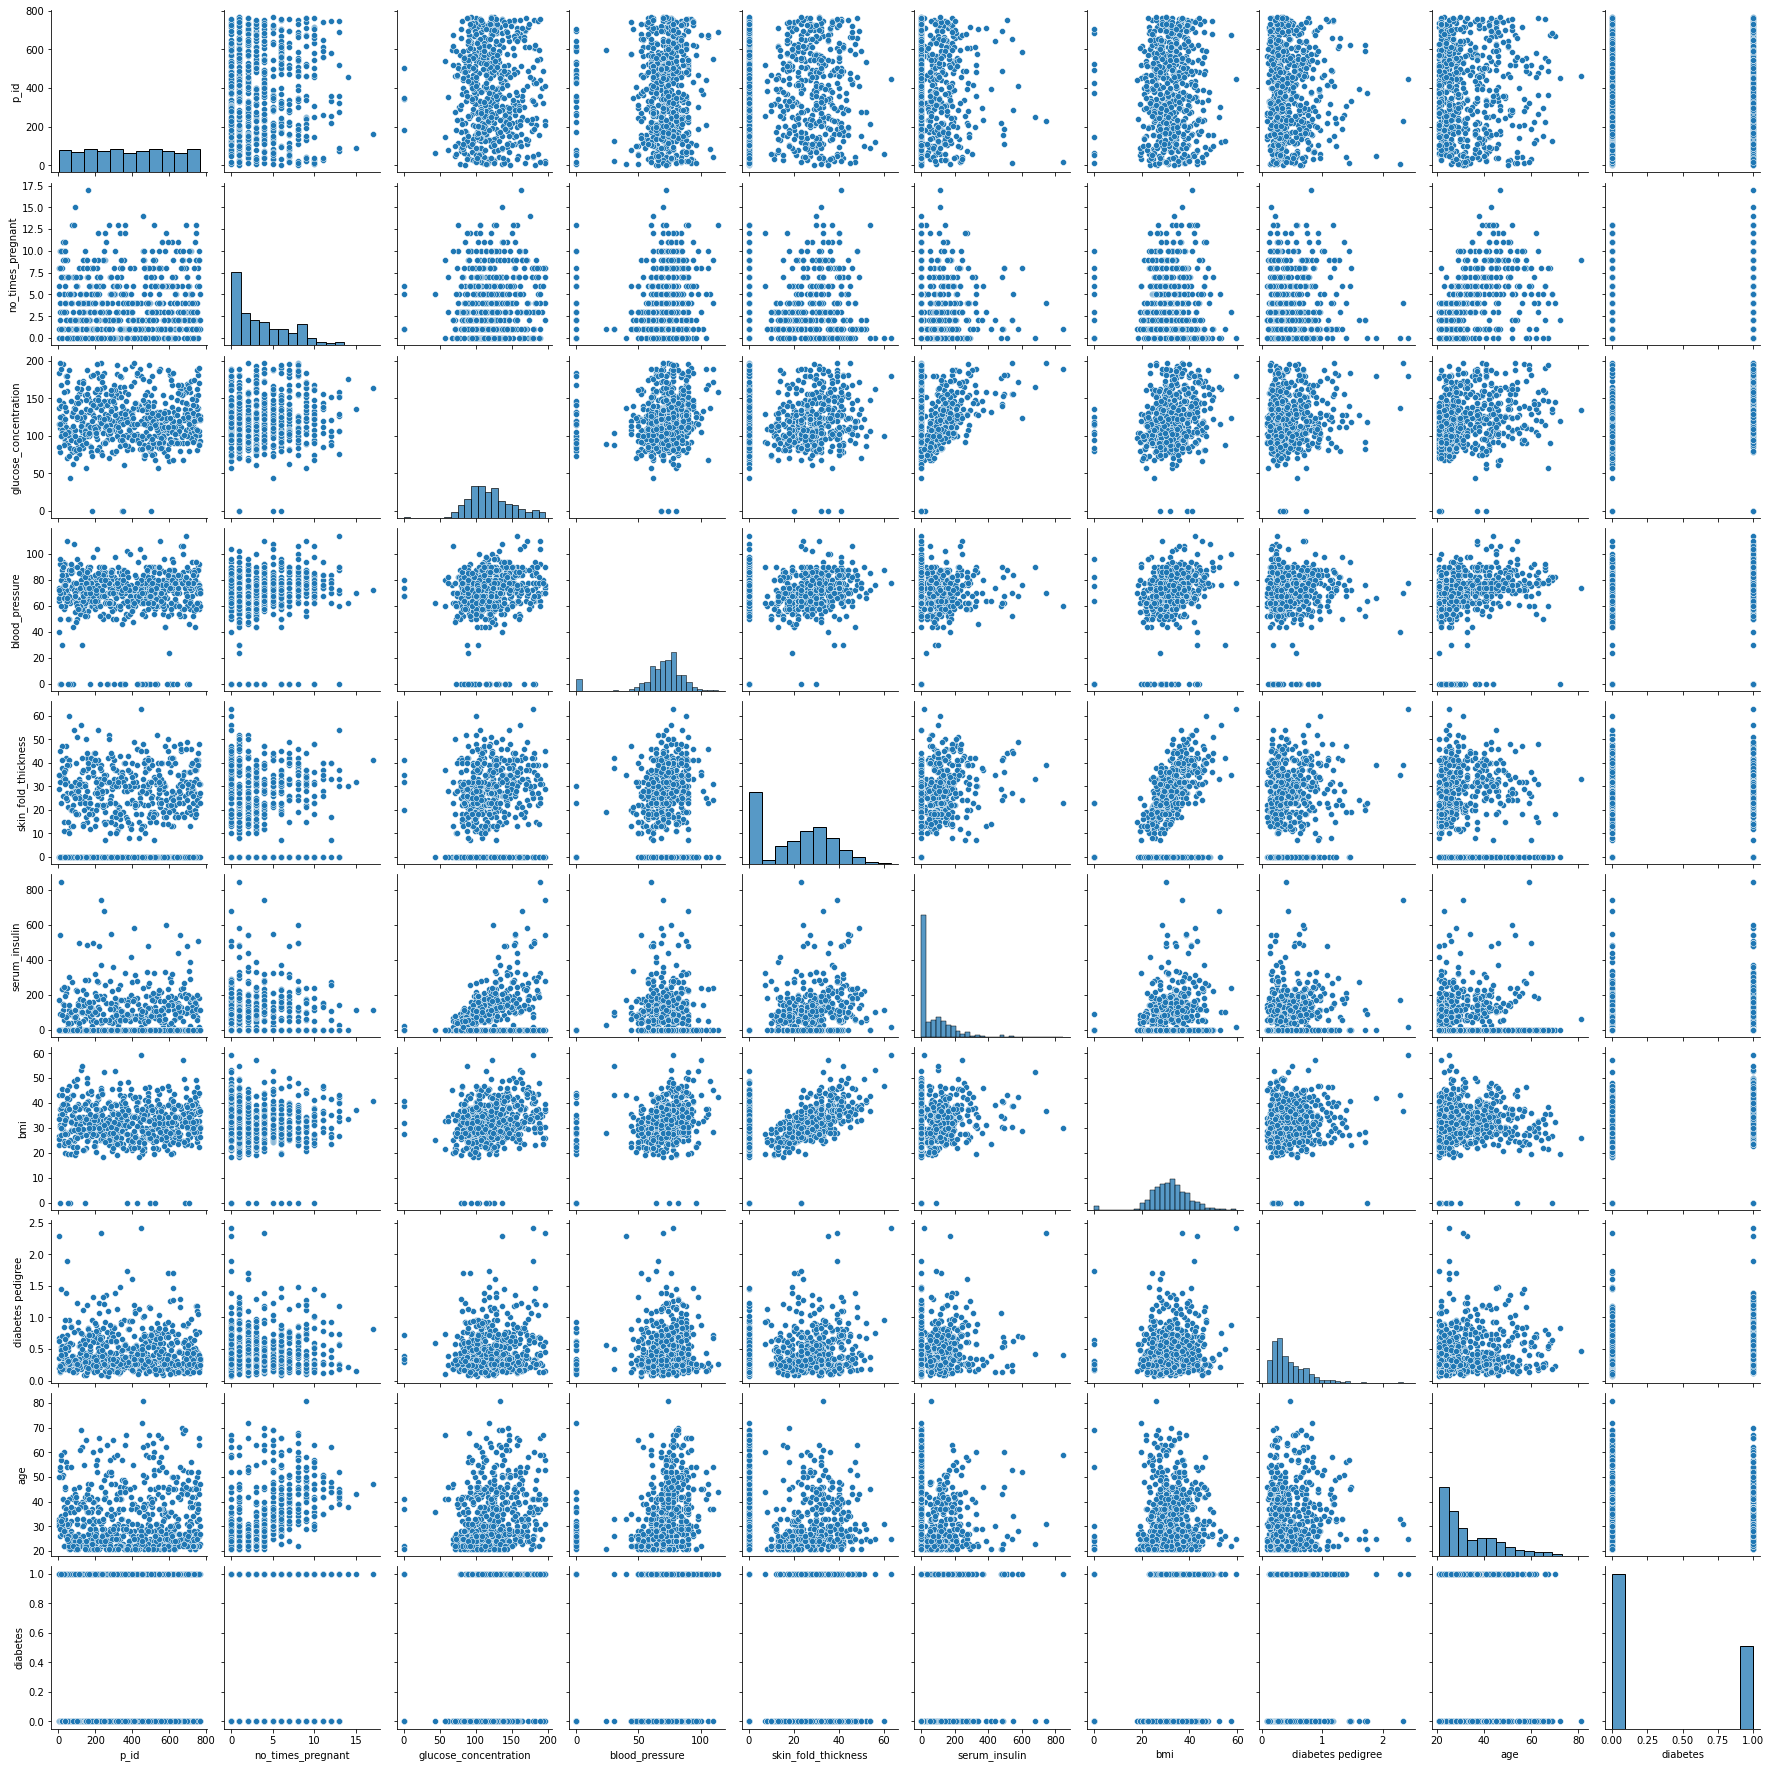

In [9]:
sns.pairplot(train)

# Statistical summary 

In [10]:
train.describe()

,p_id,no_times_pregnant,glucose_concentration,blood_pressure,skin_fold_thickness,serum_insulin,bmi,diabetes pedigree,age,diabetes
count,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000
mean,385.773616,3.853420,120.542345,68.765472,20.244300,79.355049,31.909935,0.466342,33.325733,0.348534
std,223.603024,3.358126,31.252286,19.914836,15.886083,117.709950,8.007699,0.331090,11.929569,0.476895
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,191.250000,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.240250,24.000000,0.000000
50%,387.000000,3.000000,117.000000,72.000000,23.000000,17.000000,32.000000,0.361000,29.000000,0.000000
75%,572.750000,6.000000,139.000000,80.000000,32.000000,126.000000,36.600000,0.613500,41.000000,1.000000
max,768.000000,17.000000,197.000000,114.000000,63.000000,846.000000,59.400000,2.420000,81.000000,1.000000


# Correlation Matrix

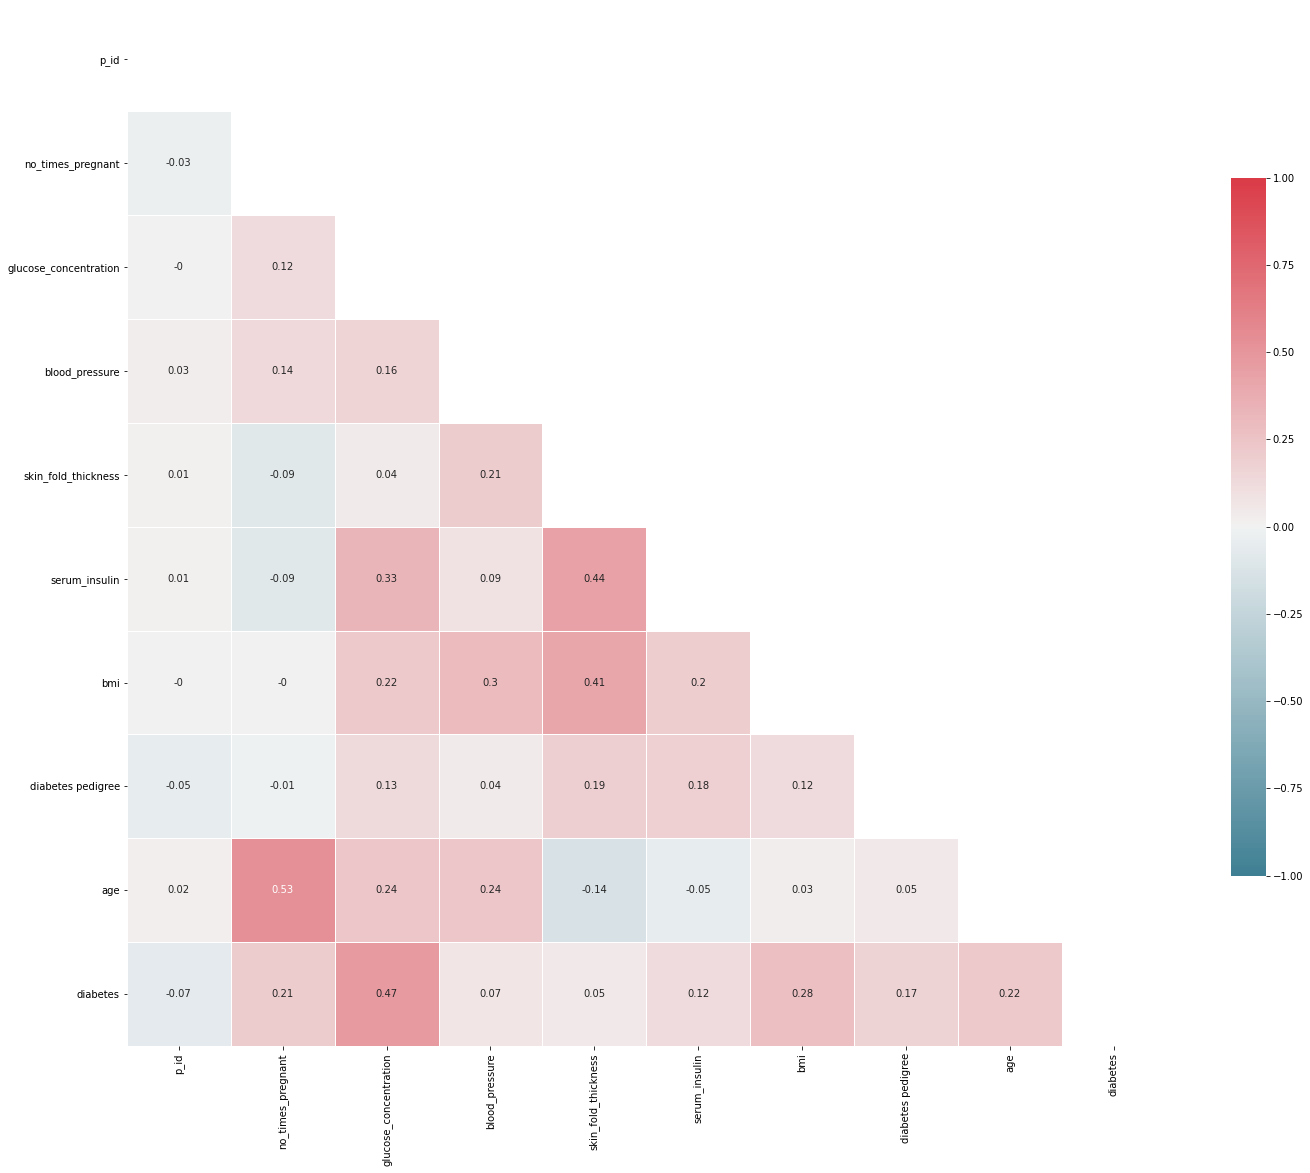

In [11]:
# Generate and visualize the correlation matrix
corr = train.corr().round(2)

# Mask for the upper triangle
mask = np.zeros_like(corr, dtype=np.bool)
mask[np.triu_indices_from(mask)] = True

# Set figure size
f, ax = plt.subplots(figsize=(20, 20))

# Define custom colormap
cmap = sns.diverging_palette(220, 10, as_cmap=True)

# Draw the heatmap
sns.heatmap(corr, mask=mask, cmap=cmap, vmin=-1, vmax=1, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5}, annot=True)

plt.tight_layout()

# Heatmap

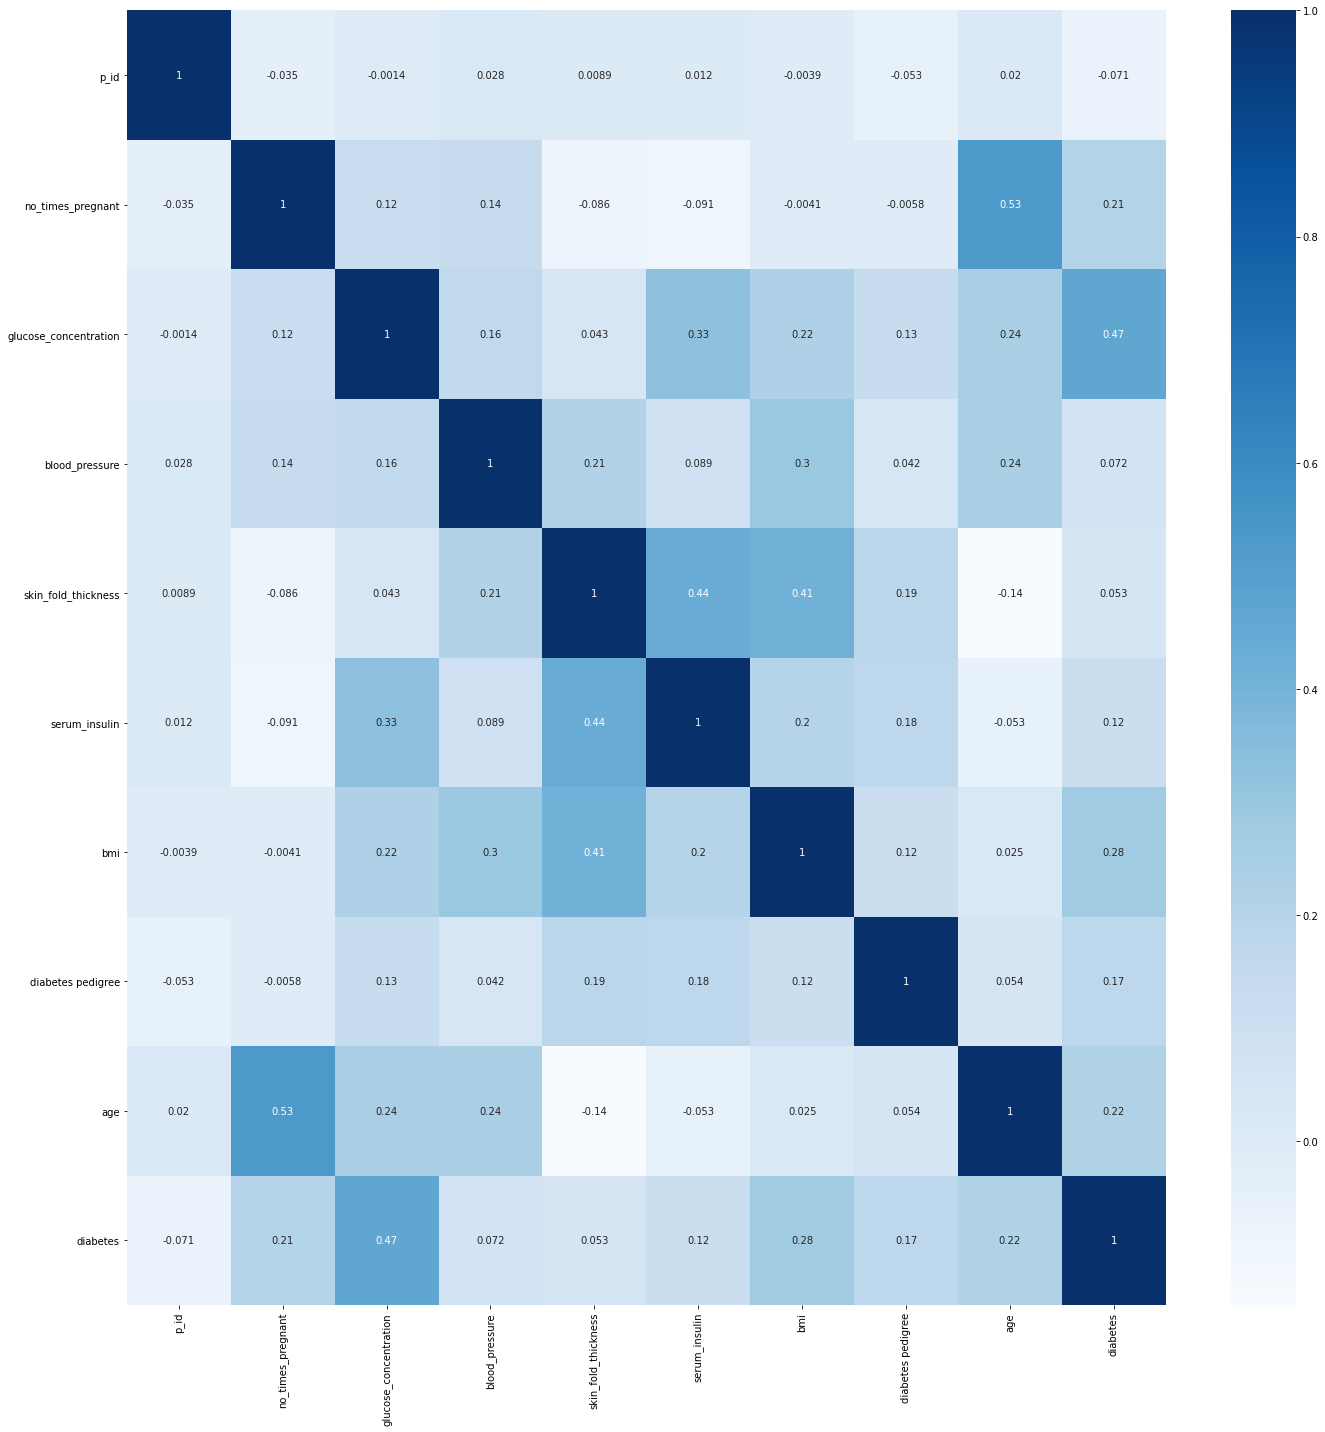

In [12]:
plt.figure(figsize=(20,20))
sns.heatmap(train.corr(), cmap='Blues', annot=True)
plt.tight_layout()

# Density plot of Age

/opt/conda/lib/python3.7/site-packages/seaborn/distributions.py:949: MatplotlibDeprecationWarning: Case-insensitive properties were deprecated in 3.3 and support will be removed two minor releases later
  scout = self.ax.fill_between([], [], **plot_kws)
/opt/conda/lib/python3.7/site-packages/seaborn/distributions.py:993: MatplotlibDeprecationWarning: Case-insensitive properties were deprecated in 3.3 and support will be removed two minor releases later
  support, fill_from, density, **artist_kws


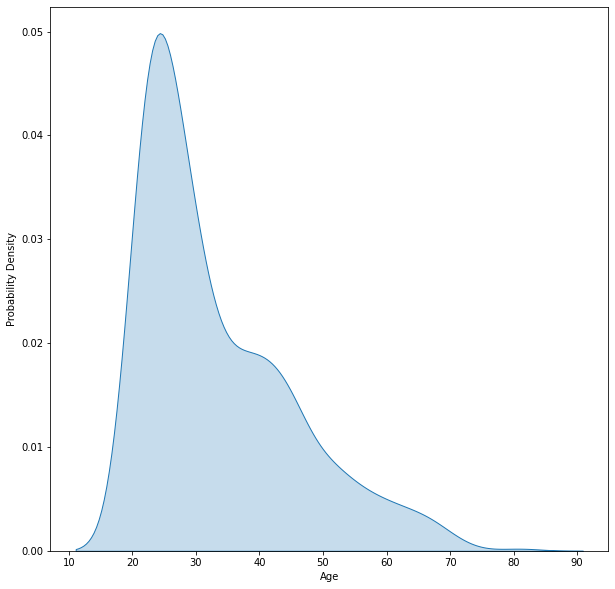

In [13]:
plt.figure(figsize=(10,10))
sns.kdeplot(train['age'], shade=True, Label="Age")
plt.xlabel('Age')
plt.ylabel('Probability Density')
plt.show()

# Age prone to dibetes

In [14]:
train['age'].describe(percentiles=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,0.95,1])

count    614.000000
mean      33.325733
std       11.929569
min       21.000000
10%       22.000000
20%       23.000000
30%       25.000000
40%       27.000000
50%       29.000000
60%       33.000000
70%       38.000000
80%       43.000000
90%       51.000000
95%       58.000000
100%      81.000000
max       81.000000
Name: age, dtype: float64

# Inference
Maximum age is within the range of 20to 30 years. From the plot it is clear that max age is 25 year who are having diabties

# Diabatic Counts

In [15]:
train['diabetes'].value_counts()

0    400
1    214
Name: diabetes, dtype: int64

# Histogram of total DIBATIC and NON-DIBATIC 

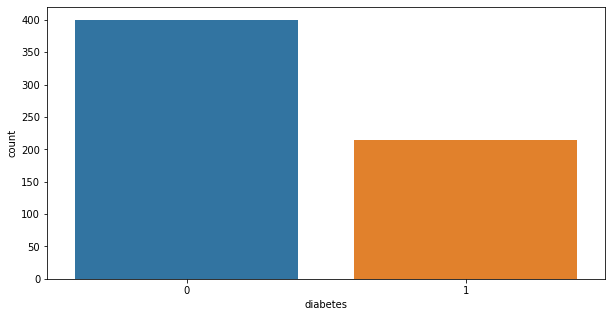

In [16]:
plt.figure(figsize=(10,5))
sns.countplot(x='diabetes', data=train)
plt.show()

In [17]:
X=train.drop(['diabetes'], axis=1)
y=train['diabetes']

In [18]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.3, random_state=7)

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [20]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [21]:
lr=LogisticRegression()
lr.fit(X_train, y_train)

/opt/conda/lib/python3.7/site-packages/sklearn/linear_model/_logistic.py:765: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG)


LogisticRegression()

# Fitting the model

In [22]:
y_pred=lr.predict(X_train)

In [23]:
from sklearn import metrics

# Model Evaluation

In [24]:
print("Accuracy Score:-", metrics.accuracy_score(y_train, y_pred))
print("F1 Score:-", metrics.f1_score(y_train, y_pred))
print("Average Precision Score:-", metrics.average_precision_score(y_train, y_pred))
print("Log Loss:-", metrics.log_loss(y_train, y_pred))
print("Precision Score:-", metrics.precision_score(y_train, y_pred))
print("Recall Score:-", metrics.recall_score(y_train, y_pred))
print("ROC-AUC Score:-", metrics.roc_auc_score(y_train, y_pred))

Accuracy Score:- 0.7808857808857809
F1 Score:- 0.6384615384615385
Average Precision Score:- 0.5607560548079654
Log Loss:- 7.567994798699162
Precision Score:- 0.7280701754385965
Recall Score:- 0.5684931506849316
ROC-AUC Score:- 0.7294762573212644


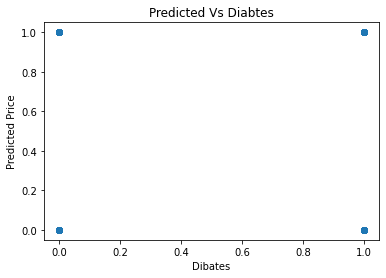

In [25]:
# visualize the difference between the actual and predicted price 
plt.scatter(y_train, y_pred)
plt.xlabel("Dibates")
plt.ylabel("Predicted Price")
plt.title("Predicted Vs Diabtes")
plt.show()

/opt/conda/lib/python3.7/site-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


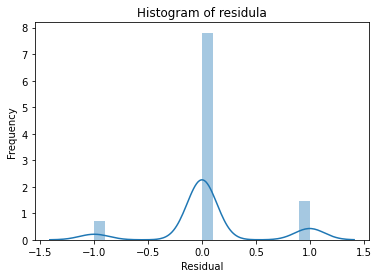

In [26]:
sns.distplot(y_train-y_pred)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Histogram of residula")
plt.show()

In [27]:
# Predicting the Test data with model 
y_test_pred=lr.predict(X_test)

# Model Evaluation of Test datase

In [28]:
lr_acc=metrics.accuracy_score(y_test, y_test_pred)
print("Accuracy Score:-",lr_acc)
print("F1 Score:-", metrics.f1_score(y_test, y_test_pred))
print("Average Precision Score:-", metrics.average_precision_score(y_test, y_test_pred))
print("Log Loss:-", metrics.log_loss(y_test, y_test_pred))
print("Precision Score:-", metrics.precision_score(y_test, y_test_pred))
print("Recall Score:-", metrics.recall_score(y_test, y_test_pred))
print("ROC-AUC Score:-", metrics.roc_auc_score(y_test, y_test_pred))

Accuracy Score:- 0.7621621621621621
F1 Score:- 0.6333333333333334
Average Precision Score:- 0.5705332028861441
Log Loss:- 8.214688409405907
Precision Score:- 0.7307692307692307
Recall Score:- 0.5588235294117647
ROC-AUC Score:- 0.7195827048768225


In [29]:
cfm=confusion_matrix(y_test, y_test_pred)
trueNegative=cfm[0][0]
falsePossitive=cfm[0][1]
false_negative=cfm[1][0]
truePositive=cfm[1][1]

In [30]:
print("Confusion Matrix", cfm)

Confusion Matrix [[103  14]
 [ 30  38]]


In [31]:
print("true negative", trueNegative)
print("False Positive", falsePossitive)
print("false Negative", false_negative)
print("True Positive", truePositive)

true negative 103
False Positive 14
false Negative 30
True Positive 38


In [32]:
print("correct prediction", 
      round((trueNegative+truePositive)/len(y_test_pred)*100, 1),'%')

correct prediction 76.2 %


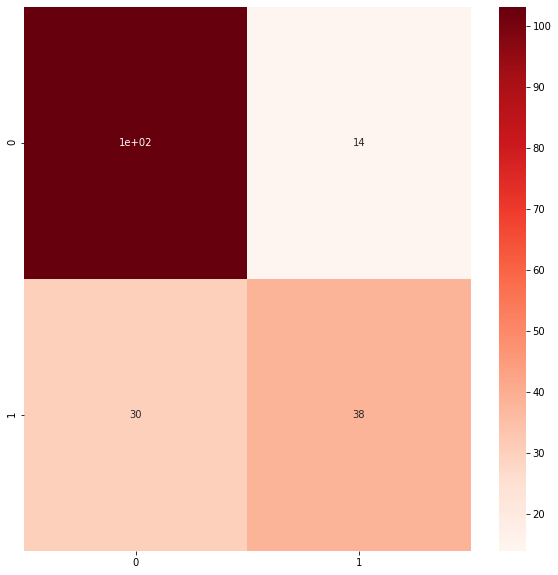

In [33]:
cfm_df=pd.DataFrame(cfm, range(2), range(2))
plt.figure(figsize=(10,10))
sns.heatmap(cfm_df, cmap='Reds', annot=True)
plt.show()

# Crross table for Confusion Matrix

In [34]:
pd.crosstab(y_test, y_test_pred, rownames=['True'], colnames=['Predicted'], margins=True)

Predicted,0,1,All
True,,,
0,103,14,117
1,30,38,68
All,133,52,185


In [35]:
from sklearn.metrics import classification_report

In [36]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.77      0.88      0.82       117
           1       0.73      0.56      0.63        68

    accuracy                           0.76       185
   macro avg       0.75      0.72      0.73       185
weighted avg       0.76      0.76      0.75       185



# ROC-AUC 

In [37]:
y_test_pred_prob=lr.predict_proba(X_test)[:,1]

In [38]:
from sklearn.metrics import roc_curve

In [39]:
fpr, tpr,thresholds=roc_curve(y_test,y_test_pred_prob)

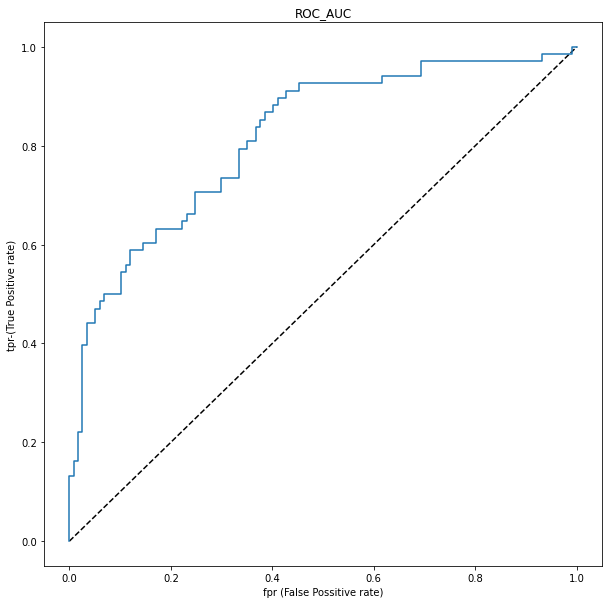

In [40]:
plt.figure(figsize=(10,10))
plt.plot([0,1],[0,1],'k--')
plt.plot(fpr, tpr, label='Logistic Regression')
plt.xlabel("fpr (False Possitive rate)")
plt.ylabel("tpr-(True Positive rate)")
plt.title("ROC_AUC")
plt.show()

# XGBoost classification

In [41]:
from xgboost import XGBClassifier
xgb=XGBClassifier()
xgb.fit(X_train, y_train)

[11:25:51] WARNING: ../src/learner.cc:1061: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.


/opt/conda/lib/python3.7/site-packages/xgboost/sklearn.py:888: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)


XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=1, gamma=0, gpu_id=-1,
              importance_type='gain', interaction_constraints='',
              learning_rate=0.300000012, max_delta_step=0, max_depth=6,
              min_child_weight=1, missing=nan, monotone_constraints='()',
              n_estimators=100, n_jobs=4, num_parallel_tree=1, random_state=0,
              reg_alpha=0, reg_lambda=1, scale_pos_weight=1, subsample=1,
              tree_method='exact', validate_parameters=1, verbosity=None)

# FItting the model

In [42]:
y_pred=xgb.predict(X_train)

# Mode Evaluation

In [43]:
print("Accuracy Score:-", metrics.accuracy_score(y_train, y_pred))
print("F1 Score:-", metrics.f1_score(y_train, y_pred))
print("Average Precision Score:-", metrics.average_precision_score(y_train, y_pred))
print("Log Loss:-", metrics.log_loss(y_train, y_pred))
print("Precision Score:-", metrics.precision_score(y_train, y_pred))
print("Recall Score:-", metrics.recall_score(y_train, y_pred))
print("ROC-AUC Score:-", metrics.roc_auc_score(y_train, y_pred))

Accuracy Score:- 1.0
F1 Score:- 1.0
Average Precision Score:- 1.0
Log Loss:- 9.992007221626413e-16
Precision Score:- 1.0
Recall Score:- 1.0
ROC-AUC Score:- 1.0


In [44]:
# Predicting the Test data with model 
y_test_pred=xgb.predict(X_test)

# Mode Evaluation of Test dataset

In [45]:
xgb_acc=metrics.accuracy_score(y_test, y_test_pred)
print("Accuracy Score:-",xgb_acc)
print("F1 Score:-", metrics.f1_score(y_test, y_test_pred))
print("Average Precision Score:-", metrics.average_precision_score(y_test, y_test_pred))
print("Log Loss:-", metrics.log_loss(y_test, y_test_pred))
print("Precision Score:-", metrics.precision_score(y_test, y_test_pred))
print("Recall Score:-", metrics.recall_score(y_test, y_test_pred))
print("ROC-AUC Score:-", metrics.roc_auc_score(y_test, y_test_pred))

Accuracy Score:- 0.7189189189189189
F1 Score:- 0.6060606060606061
Average Precision Score:- 0.5189984101748808
Log Loss:- 9.70830033985773
Precision Score:- 0.625
Recall Score:- 0.5882352941176471
ROC-AUC Score:- 0.6915535444947211


# Claculation

In [46]:
cfm=confusion_matrix(y_test, y_test_pred)
trueNegative=cfm[0][0]
falsePossitive=cfm[0][1]
false_negative=cfm[1][0]
truePositive=cfm[1][1]

In [47]:
print("Confusion Matrix", cfm)

Confusion Matrix [[93 24]
 [28 40]]


In [48]:
print("true negative", trueNegative)
print("False Positive", falsePossitive)
print("false Negative", false_negative)
print("True Positive", truePositive)

true negative 93
False Positive 24
false Negative 28
True Positive 40


# Accuracy of the model(XGBoost Classifier)

In [49]:
print("correct prediction", 
      round((trueNegative+truePositive)/len(y_test_pred)*100, 1),'%')

correct prediction 71.9 %


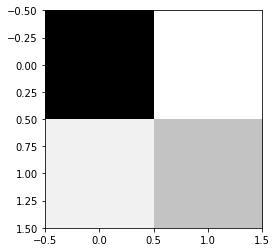

In [50]:
plt.imshow(cfm, cmap='binary')

In [51]:
z=cfm

In [52]:
print(z)

[[93 24]
 [28 40]]


# Confusion Matrix Visualization

<AxesSubplot:>

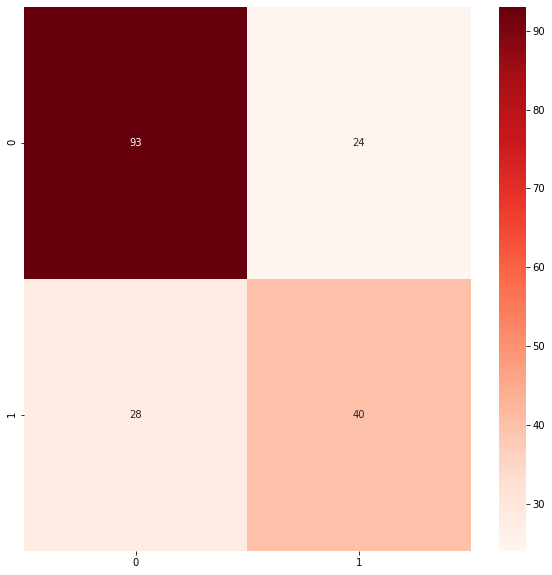

In [53]:

z_df=pd.DataFrame(z, range(2), range(2))
plt.figure(figsize=(10,10))
sns.heatmap(z_df, cmap='Reds', annot=True)

# Summary table of Precision, Recall, F1-Score, Support

In [54]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.77      0.79      0.78       117
           1       0.62      0.59      0.61        68

    accuracy                           0.72       185
   macro avg       0.70      0.69      0.69       185
weighted avg       0.72      0.72      0.72       185



# ROC-AUC

In [55]:
y_test_pred_prob=xgb.predict_proba(X_test)[:,1]

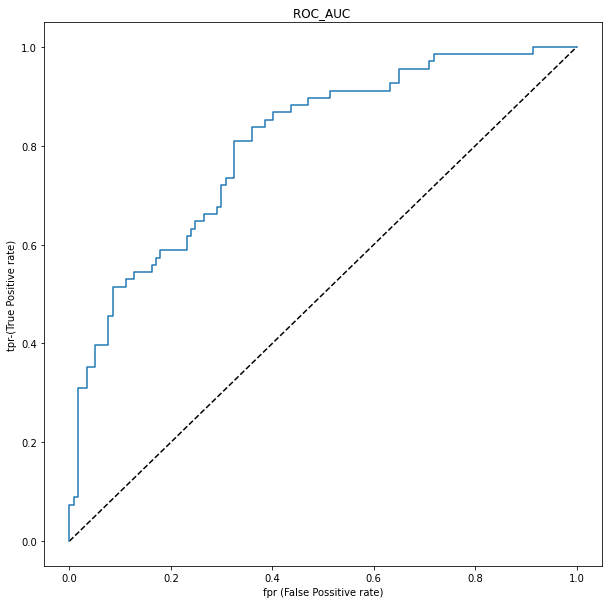

In [56]:
from sklearn.metrics import roc_curve
fpr, tpr,thresholds=roc_curve(y_test,y_test_pred_prob)
plt.figure(figsize=(10,10))
plt.plot([0,1],[0,1],'k--')
plt.plot(fpr, tpr, label='XGBoost')
plt.xlabel("fpr (False Possitive rate)")
plt.ylabel("tpr-(True Positive rate)")
plt.title("ROC_AUC ")
plt.show()

# Random Forest Classifier

In [57]:
from sklearn.ensemble import RandomForestClassifier
rfc=RandomForestClassifier()
rfc.fit(X_train, y_train)

RandomForestClassifier()

# Fitting The model

In [58]:
y_pred=rfc.predict(X_train)

# Model Evaluation

In [59]:
print("Accuracy Score:-", metrics.accuracy_score(y_train, y_pred))
print("F1 Score:-", metrics.f1_score(y_train, y_pred))
print("Average Precision Score:-", metrics.average_precision_score(y_train, y_pred))
print("Log Loss:-", metrics.log_loss(y_train, y_pred))
print("Precision Score:-", metrics.precision_score(y_train, y_pred))
print("Recall Score:-", metrics.recall_score(y_train, y_pred))
print("ROC-AUC Score:-", metrics.roc_auc_score(y_train, y_pred))

Accuracy Score:- 1.0
F1 Score:- 1.0
Average Precision Score:- 1.0
Log Loss:- 9.992007221626413e-16
Precision Score:- 1.0
Recall Score:- 1.0
ROC-AUC Score:- 1.0


In [60]:
# Predicting the Test data with model 
y_test_pred=rfc.predict(X_test)

# Model Evaluation for Test dataset 

In [61]:
rfc_acc=metrics.accuracy_score(y_test, y_test_pred)
print("Accuracy Score:-",rfc_acc)
print("F1 Score:-", metrics.f1_score(y_test, y_test_pred))
print("Average Precision Score:-", metrics.average_precision_score(y_test, y_test_pred))
print("Log Loss:-", metrics.log_loss(y_test, y_test_pred))
print("Precision Score:-", metrics.precision_score(y_test, y_test_pred))
print("Recall Score:-", metrics.recall_score(y_test, y_test_pred))
print("ROC-AUC Score:-", metrics.roc_auc_score(y_test, y_test_pred))

Accuracy Score:- 0.7567567567567568
F1 Score:- 0.6153846153846154
Average Precision Score:- 0.5619285552058662
Log Loss:- 8.401380175878774
Precision Score:- 0.7346938775510204
Recall Score:- 0.5294117647058824
ROC-AUC Score:- 0.7091503267973855


# Claculation 

In [62]:
cfm=confusion_matrix(y_test, y_test_pred)
trueNegative=cfm[0][0]
falsePossitive=cfm[0][1]
false_negative=cfm[1][0]
truePositive=cfm[1][1]

In [63]:
print("Confusion Matrix", cfm)

Confusion Matrix [[104  13]
 [ 32  36]]


# True Positive, True Negative, False Positive and False Negative

In [64]:
print("true negative", trueNegative)
print("False Positive", falsePossitive)
print("false Negative", false_negative)
print("True Positive", truePositive)

true negative 104
False Positive 13
false Negative 32
True Positive 36


# Accuracy of Random Forest


In [65]:
print("correct prediction", 
      round((trueNegative+truePositive)/len(y_test_pred)*100, 1),'%')

correct prediction 75.7 %


# Visualization of the Confusion Matrix
*  a confusion matrix, also known as an error matrix
*  specific table layout that allows visualization of the performance of an algorithm, typically a supervised learning one
*  Each row of the matrix represents predicted class, while each column represents actual class
# USE
* used for evaluating the performance of a classification model,
* matrix compares the actual target values with  predicted by the machine learning model


<AxesSubplot:>

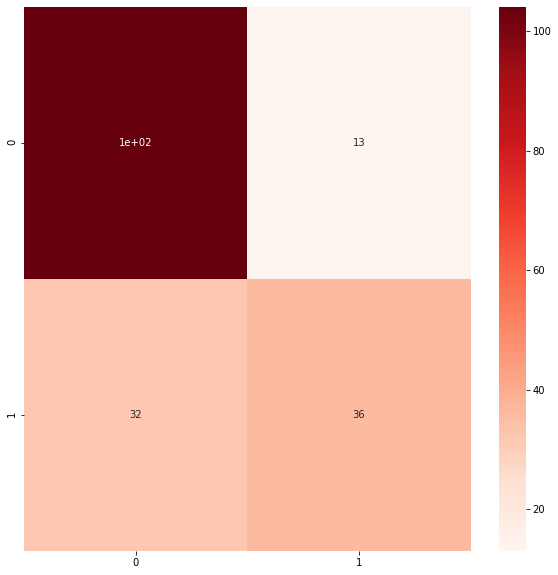

In [66]:

cfm_df=pd.DataFrame(cfm, range(2), range(2))
plt.figure(figsize=(10,10))
sns.heatmap(cfm_df, cmap='Reds', annot=True)

# Summary table of Precision, Recall, F1-Score, Support

In [67]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.76      0.89      0.82       117
           1       0.73      0.53      0.62        68

    accuracy                           0.76       185
   macro avg       0.75      0.71      0.72       185
weighted avg       0.75      0.76      0.75       185



# ROC -AUC

In [68]:
y_test_pred_prob=xgb.predict_proba(X_test)[:,1]

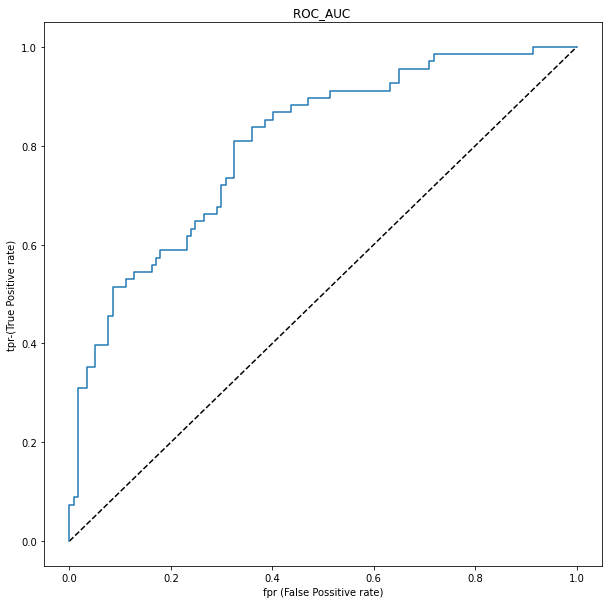

In [69]:
from sklearn.metrics import roc_curve
fpr, tpr,thresholds=roc_curve(y_test,y_test_pred_prob)
plt.figure(figsize=(10,10))
plt.plot([0,1],[0,1],'k--')
plt.plot(fpr, tpr, label='Random Forest')
plt.xlabel("fpr (False Possitive rate)")
plt.ylabel("tpr-(True Positive rate)")
plt.title("ROC_AUC ")
plt.show()

# Evaluation Comparisoon of the all model

In [70]:
print("Logistic Regression", lr_acc*100)
print("XGBosst", xgb_acc*100)
print("Random Forest", rfc_acc*100)

Logistic Regression 76.21621621621621
XGBosst 71.89189189189189
Random Forest 75.67567567567568


# Conclusion 
Logistic Regression is working very good 
* The submission will be done using Logistic Model

# Logistic Regresssion

# Submission Code

In [71]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()

In [72]:
model.fit(X_train, y_train)

/opt/conda/lib/python3.7/site-packages/sklearn/linear_model/_logistic.py:765: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG)


LogisticRegression()

In [73]:
prediction=model.predict(X_train)

In [74]:
test_x=test

In [75]:
predicted=model.predict(test_x)

In [76]:
my_submission=pd.DataFrame({'p_id':test.p_id, 'diabetes':predicted})


In [77]:
my_submission.to_csv('submission2.csv', index=False)


# End